# Creating a multi-agent chatbot with routing and orchestration

In [1]:
"""Real routing-and-orchestration lab for a LangGraph lecture.

This lab routes a question to one or more real specialist nodes:
    - Weather specialist: OpenWeatherMap
    - Web specialist: Tavily, with DuckDuckGo as a fallback
    - Paper specialist: LangChain ArxivLoader downloads paper PDFs and extracts text

The synthesizer combines every selected specialist result into one answer.

Install:
    pip install -U langchain langgraph langchain-groq \
        langchain-tavily langchain-community arxiv pymupdf requests python-dotenv

Required .env values:
    GROQ_API_KEY=...
    TAVILY_API_KEY=...
    OPENWEATHER_API_KEY=...
"""

import json
import os
import warnings


import requests
from dotenv import load_dotenv
from langchain.chat_models import init_chat_model
from langchain_community.tools import DuckDuckGoSearchRun

from langchain_tavily import TavilySearch
from langchain.tools import tool
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.graph import END, START, StateGraph

from pydantic import BaseModel, Field #for structured output 
from typing import Literal, TypedDict #for langgraph state

from langchain_community.document_loaders import ArxivLoader

from langchain.messages import HumanMessage, SystemMessage, AIMessage, ToolMessage


load_dotenv()
warnings.filterwarnings("ignore", category=DeprecationWarning)

WEATHER_API_KEY = os.getenv("OPENWEATHER_API_KEY")

# The primary model makes routing and final synthesis decisions.
# llm_primary = init_chat_model(
#     model="llama-3.3-70b-versatile", model_provider="groq"
# )

llm_primary = init_chat_model(
    model="gpt-5.4-nano", model_provider="openai"
)


/Users/nali/Documents/YTLLMs/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/var/folders/l9/f7m3nyf55s1947yhx1spp9fw0000gp/T/ipykernel_7634/2411809497.py:28: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.tools import DuckDuckGoSearchRun


# Create ResearchState as graphState 

In [2]:
class ResearchState(TypedDict):
    question:str 

    routes:list[str]

    weather_result:str
    web_result:str
    paper_result:str
    RAG_result:str

    final_answer:str

# Create weather node/agent/worker  

## getWeather tool

In [3]:
@tool
def getWeather(location:str)->str:
    """Return the weather information based on the given location and or zipcode"""
    url = "https://api.openweathermap.org/data/2.5/weather?"

    params={
        "q":location,
        "appid":WEATHER_API_KEY,
        "units":"imperial"
    }

    try:
        response = requests.get(url,params=params,timeout=10)
        return response.json()
    except:
        return f"The requested weather information is not available"

## create structured output for getWeather tool

In [4]:
class WeatherRequest(BaseModel):
    location:str = Field(description="The city to look up")

weather_location_llm = llm_primary.with_structured_output(WeatherRequest)

In [5]:
weather_location_llm.invoke("weather in Cincinati")

WeatherRequest(location='Cincinati')

### create the weather node

In [6]:
def run_weather_specialist(state:ResearchState)->ResearchState: 
    """Extract location and then return weather information"""

    request = weather_location_llm.invoke([
        SystemMessage(content="extract location from the query"),
        HumanMessage(content=f"{state["question"]}")
    ]
    )

    response = getWeather.invoke({"location":request.location})

    return {"weather_result":response}

### test the weather node 

In [7]:
initial_state = {
    "question":"weather in Peoria"
}
#run_weather_specialist(initial_state)

# Create web_search node 

In [8]:
# Search tool using Tavily 
from langchain_tavily import TavilySearch

web_search = TavilySearch(
    max_results=3, 
    topic="general",
    search_depth="basic"
)


# Create duckduckgosearch 

from langchain_community.tools import DuckDuckGoSearchRun 

ddg_search = DuckDuckGoSearchRun()

## Create run_web_special node/agent 

In [9]:
def run_web_specialist(state:ResearchState)->ResearchState: 
    """return web search result"""
    try:
        result = web_search.invoke({"query":state["question"]})
        return {"web_result":json.dumps(result)}
    except Exception:
        result = ddg_search.invoke({"query":state["question"]})
        return {"web_result":json.dumps(result)}

In [10]:
# test the web_search node 
initial_state = {
    "question":"Top news today is USA"
}
run_web_specialist(initial_state)

{'web_result': '{"query": "Top news today is USA", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.usatoday.com", "title": "USA TODAY - Breaking News and Latest News Today", "content": "The Fall Reset \\ud83d\\udecd\\ufe0f Explore Marvel comics America\'s birthday \\ud83c\\udf82 Check home prices \\ud83c\\udfe0\\n\\nAriana Grande taking a career break after \'ongoing public scrutiny\'\\n\\nDating has gotten too expensive. So singles are \\u2018infladating\\u2019\\n\\nDemocratic socialist platform includes abolition of Senate, police [...] Your Daily PLAY\\n\\nSpider-Man has always had relationship drama. Just look\\u2026 Read your daily horoscope for Sunday, August 2, 2026. Get a little help to today\'s crossword with your morning\\u2026 How fast can you solve today\\u2019s daily crossword puzzle?\\n\\nMore Top Stories\\n\\nDiscover\\n\\n Exclusive: RFK Jr. to host cooking show featuring\\u2026 Trump wants a stronger northern border. The view

# Create research_paper node/agent

## Create load_argix_paper tool

In [11]:
import arxiv
arxiv.Client.query_url_format = "https://export.arxiv.org/api/query?{}"
#client = arxiv.Client()
@tool
def load_arxiv_papers(query:str, max_results:int=2): 
    """Download research paper from arxiv"""

    try:
        loader = ArxivLoader(
            query=query,
            load_max_docs=max_results,
            load_all_available_meta= True,
            doc_content_chars_max=12000
        )

        documents = loader.load()

        papers = [{
                "title":document.metadata.get("Title","unknown title"),
                "authors":document.metadata.get("Authors","unknown authors"),
                "content":document.page_content
        }
        for document in documents
        ]

        return json.dumps(papers)
    except Exception as error:
        return f"Error in loading papers. {error}"

In [12]:
#response = load_arxiv_papers.invoke({"query":"AI and ML", "max_results":2})

#print(response)

## Create run_paper_specialist 

In [13]:
def run_paper_specialist(state:ResearchState)->ResearchState:
    """Resturn arxiv paper and summerzie the context"""
    papers = load_arxiv_papers.invoke({"query":state["question"],"max_results":2})

    summary = llm_primary.invoke(
        [
            SystemMessage(content="""Summerize the research paper based on the user question"""),
            HumanMessage(content=f"user Question: {state["question"]}, \n Papers: {papers}")
        ]
    )

    return {"paper_results":summary}

# Create RAG agent node 

In [14]:
#Creating embeddings
from langchain_huggingface import HuggingFaceEmbeddings

embeddings = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-mpnet-base-v2",
    encode_kwargs={"normalize_embeddings": True,
            'batch_size':32
                   },
    
)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 20133.79it/s]


In [15]:
# get the vectore_store 
from langchain_chroma import Chroma

vector_store = Chroma(
    collection_name="example_collection",
    embedding_function=embeddings,
    persist_directory="./chroma_langchain_db",  # Where to save data locally, remove if not necessary
)

In [16]:
# get your retriever
retriever = vector_store.as_retriever(
    search_type="similarity",
    search_kwargs={"k":2}
)

In [17]:
## tool creation
from langchain_core.tools import tool 

@tool 
def get_documents(query:str)->str: 
    """This tool will return the retrieved information"""
    docs = retriever.invoke(query)

    return "\n\n".join(doc.page_content for doc in docs)

In [18]:
get_documents.invoke("How to create a langchain agent?")

"> ## Documentation Index\n> Fetch the complete documentation index at: https://docs.langchain.com/llms.txt\n> Use this file to discover all available pages before exploring further.\n\n# Quickstart\n\nThis quickstart demonstrates how to build a calculator agent using the LangGraph Graph API or the Functional API.\n\n<Tip>\n  **Using an AI coding assistant?**\n\n  * Install the [LangChain Docs MCP server](/use-these-docs) to give your agent access to up-to-date LangChain documentation and examples.\n  * Install [LangChain Skills](https://github.com/langchain-ai/langchain-skills) to improve your agent's performance on LangChain ecosystem tasks.\n</Tip>\n\n* [Use the Graph API](#use-the-graph-api) if you prefer to define your agent as a graph of nodes and edges.\n* [Use the Functional API](#use-the-functional-api) if you prefer to define your agent as a single function.\n\n> ## Documentation Index\n> Fetch the complete documentation index at: https://docs.langchain.com/llms.txt\n> Use th

In [19]:
## Create a RAG agent 
from langchain.agents import create_agent

RAG_agent = create_agent(
    model=llm_primary, 
    tools=[get_documents],
    system_prompt="""Use get_documents tool for answering agent, deep agent, langchain and langgraph related queries."""
)

In [20]:
RAG_agent.invoke({
    "messages":[
    SystemMessage(content="You are a helpfull assistant"),   
    HumanMessage(content="How to create a langchain agent?")
    ]
    })

{'messages': [SystemMessage(content='You are a helpfull assistant', additional_kwargs={}, response_metadata={}, id='6fde2e14-6b08-4006-8333-f62e98a0f88d'),
  HumanMessage(content='How to create a langchain agent?', additional_kwargs={}, response_metadata={}, id='e98010b2-e80b-4c91-8e5d-c5c14f5ae7bb'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 45, 'prompt_tokens': 166, 'total_tokens': 211, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-nano-2026-03-17', 'system_fingerprint': None, 'id': 'chatcmpl-E8s0wKnaisLDzt8HONR8CjUuw6F8z', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019fc8f5-88e9-7983-97ec-3a92bcb6cf65-0', tool_calls=[{'name': 'ge

In [21]:
try:
    result = RAG_agent.invoke({
        "messages":    [
                SystemMessage(content="""You are an helpful assistant."""),
                HumanMessage(content=f"How to create a langchain agent?")
            ]
    }
    )

    print(result["messages"])
except Exception as error:
    print(f"Faild RAG agent: {error}")

[SystemMessage(content='You are an helpful assistant.', additional_kwargs={}, response_metadata={}, id='0a13f110-0de4-4d50-b30a-798a2364ee0a'), HumanMessage(content='How to create a langchain agent?', additional_kwargs={}, response_metadata={}, id='c455f53f-9154-40be-ad1f-31d7171b829e'), AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 31, 'prompt_tokens': 166, 'total_tokens': 197, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-nano-2026-03-17', 'system_fingerprint': None, 'id': 'chatcmpl-E8s14YtXQP0AV0Z1aj038BBDpPPn4', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019fc8f5-a69c-7931-a3a1-1e7c35e7bcc9-0', tool_calls=[{'name': 'get_documents', 'a

In [22]:
result["messages"][-1].content

'Here’s a practical way to create a **LangChain agent** using the modern, “tool-calling” style (recommended). This example shows the typical pattern:\n\n1) define tools  \n2) create a prompt for the agent  \n3) create the agent (LLM + tools + prompt)  \n4) wrap it with an executor and run it  \n\n## Minimal example (Python)\n\n```python\n# pip install langchain langchain-openai\n\nfrom langchain.tools import tool\nfrom langchain_openai import ChatOpenAI\nfrom langchain.agents import AgentExecutor, create_tool_calling_agent\nfrom langchain_core.prompts import ChatPromptTemplate\n\n# 1) Define tools\n@tool\ndef add(a: int, b: int) -> int:\n    """Add two integers and return the result."""\n    return a + b\n\n@tool\ndef multiply(a: int, b: int) -> int:\n    """Multiply two integers and return the result."""\n    return a * b\n\ntools = [add, multiply]\n\n# 2) Create the LLM\nllm = ChatOpenAI(model="gpt-4o-mini", temperature=0)\n\n# 3) Create the agent prompt\nprompt = ChatPromptTemplate.

### Create the langgraph node using RAG_agent 

In [23]:
def run_RAG_specialist(state:ResearchState)->ResearchState:
    """Resturn langchain documentation"""

    result = RAG_agent.invoke({
       "messages": [
            SystemMessage(content="""You are an helpful langchain documentation"""),
            HumanMessage(content=f"user Question: {state["question"]}")
        ]
    }
    )

    return {"RAG_results":result["messages"][-1].content}

In [24]:
initial_state = {
    'question':"How to create a langgraph agent?"
}

In [25]:
run_RAG_specialist(initial_state)

{'RAG_results': 'Here’s the standard way to create a **LangGraph agent**: you define **(1) a model**, **(2) tools**, then build a **graph** that routes between an LLM “agent” step and tool-execution steps.\n\nBelow is a complete minimal pattern (LangGraph “Graph API” style).\n\n## 1) Define the model + tools\n\n```python\nfrom langchain.tools import tool\nfrom langchain.chat_models import init_chat_model\n\nmodel = init_chat_model("claude-sonnet-4-6", temperature=0)\n\n@tool\ndef get_weather(city: str) -> str:\n    """Get the weather for a city."""\n    # replace with real logic / API call\n    return f"Weather in {city}: 72°F"\n```\n\n## 2) Build a LangGraph with an “agent” node and a “tools” node\n\nTypical structure:\n- **agent node**: calls the LLM\n- **tools node**: runs any requested tool calls\n- **conditional edges**: loop until no more tool calls are requested\n\n```python\nfrom langgraph.graph import StateGraph, END\nfrom langgraph.prebuilt import ToolNode\n\nfrom typing impo

# Create router node

In [26]:
class RouteDecision(BaseModel): 
    routes: list[Literal["weather","web","paper","RAG"]] = Field(
        description="""Return the routes based on the question. Return weather for weather related query.
        return web for internet search or current affiars related query, return paper for arxiv papers and 
        other papers related query. Return RAG for agent, langchain, langgraph and deep agent related query.
        """
    )

router_llm = llm_primary.with_structured_output(RouteDecision)

In [27]:
router_llm.invoke("How to create a langgraph agent?")

RouteDecision(routes=['RAG'])

In [28]:
def router(state:ResearchState)->ResearchState:

    decision = router_llm.invoke([
        SystemMessage(content="Return routes based on the user query"),
        HumanMessage(content=f"Question:{state["question"]}")
    ])

    return {"routes":decision.routes}

## Selection the conditional routes function

In [29]:
def select_specialists(state:ResearchState)->list[str]:
    """Select the route or list of routes"""
    destinations = [] 

    if("weather" in state["routes"]):
        destinations.append("weather_specialist")
    if("web" in state["routes"]):
        destinations.append("web_specialist")
    if("paper" in state["routes"]):
        destinations.append("paper_specialist")
    if("RAG" in state["routes"]):
            destinations.append("RAG_specialist")

    return destinations


# Create Synthesizer node 

In [30]:
def synthesizer(state:ResearchState)->ResearchState:
    """combine the results based on the specialist nodes output"""

    evidence = [] 
    if(state.get("weather_result")):
        evidence.append(f" Weather specialist: {state["weather_result"]}")
    if(state.get("web_result")):
        evidence.append(f" Web specialist: {state["web_result"]}")
    if(state.get("paper_result")):
        evidence.append(f" Paper specialist: {state["paper_result"]}")
    if(state.get("RAG_result")):
            evidence.append(f" RAG specialist: {state["RAG_result"]}")


    response = llm_primary.invoke([
        SystemMessage(content="""You are a nice synthesizer. Your job is to combine the specialists' input as a final 
        answer to the user based on the user query.
        """),
        HumanMessage(content=f"User questions: {state["question"]} \n Specialists' input: {evidence}")
    ])


    return {"final_answer":response}

# Complete the graph 

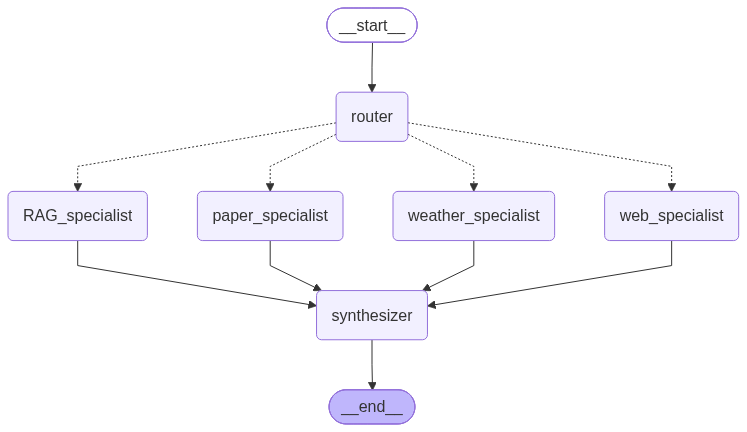

In [31]:
graph = StateGraph(ResearchState)

#Nodes
graph.add_node(router)
graph.add_node("weather_specialist",run_weather_specialist)
graph.add_node("web_specialist",run_web_specialist)
graph.add_node("paper_specialist",run_paper_specialist)
graph.add_node("RAG_specialist",run_RAG_specialist)
graph.add_node(synthesizer)

#Edges 
graph.add_edge(START,"router")
graph.add_conditional_edges(
    "router", select_specialists, ["weather_specialist","web_specialist","paper_specialist","RAG_specialist"]
)
graph.add_edge("weather_specialist","synthesizer")
graph.add_edge("web_specialist","synthesizer")
graph.add_edge("paper_specialist","synthesizer")
graph.add_edge("RAG_specialist","synthesizer")

graph.add_edge("synthesizer", END)

graph = graph.compile()
graph

## test the graph 

In [32]:
#confifure = {"configurable":{"thread_id":1}}

In [44]:
initial_state = {
    "question":"Weather in Peoria? How to create a langchain Agent?" 
}

In [45]:
try: 
    response = graph.invoke(initial_state) 
    #print(response["final_answer"].content)
except Exception as e: 
    print("error in generating final asnwer. {e}")


In [46]:
print(response["final_answer"].content)

### Weather in Peoria
Right now in **Peoria, US**:
- **Condition:** Clear sky  
- **Temperature:** **80.78°F** (feels like **83.34°F**)  
- **Today range:** **78.55°F – 84.25°F**  
- **Humidity:** **64%**  
- **Wind:** **1.25 m/s** (from **94°**), gusts **1.66 m/s**  
- **Clouds:** **0%**  
- **Visibility:** **10,000 m**  

---

### How to create a LangChain Agent (quick starter)
Here’s a common minimal pattern using a tool-calling agent (works with ChatGPT-style models).

**1) Install**
```bash
pip install langchain langchain-openai langchain-community
```

**2) Create tools**
```python
from langchain_core.tools import tool

@tool
def get_weather(city: str) -> str:
    # Replace with your real weather call
    return f"Weather for {city}: (use API here)"

@tool
def calculator(expression: str) -> str:
    return str(eval(expression))
```

**3) Build the agent + executor**
```python
from langchain_openai import ChatOpenAI
from langchain.agents import create_tool_calling_agent, AgentExec

In [47]:
print(response)

{'question': 'Weather in Peoria? How to create a langchain Agent?', 'routes': ['weather', 'RAG'], 'weather_result': {'coord': {'lon': -89.7668, 'lat': 40.7667}, 'weather': [{'id': 800, 'main': 'Clear', 'description': 'clear sky', 'icon': '01d'}], 'base': 'stations', 'main': {'temp': 80.78, 'feels_like': 83.34, 'temp_min': 78.55, 'temp_max': 84.25, 'pressure': 1015, 'humidity': 64, 'sea_level': 1015, 'grnd_level': 991}, 'visibility': 10000, 'wind': {'speed': 1.25, 'deg': 94, 'gust': 1.66}, 'clouds': {'all': 0}, 'dt': 1785783170, 'sys': {'type': 2, 'id': 2007924, 'country': 'US', 'sunrise': 1785754649, 'sunset': 1785805976}, 'timezone': -18000, 'id': 4905697, 'name': 'Peoria', 'cod': 200}, 'final_answer': AIMessage(content='### Weather in Peoria\nRight now in **Peoria, US**:\n- **Condition:** Clear sky  \n- **Temperature:** **80.78°F** (feels like **83.34°F**)  \n- **Today range:** **78.55°F – 84.25°F**  \n- **Humidity:** **64%**  \n- **Wind:** **1.25 m/s** (from **94°**), gusts **1.66 m